# 🧠 Modelo 14: Transfer Learning con MobileNetV3 + Data Augmentation

En este notebook utilizamos la arquitectura **MobileNetV3Large** preentrenada en ImageNet, aplicando **Data Augmentation** para mejorar la generalización del modelo y reducir el sobreajuste. MobileNetV3 es una arquitectura más eficiente que ResNet50, ideal para dispositivos móviles y con mejor balance entre precisión y velocidad.

---

In [ ]:
import os
import sys


os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suprime todos los mensajes (INFO, WARNING, ERROR)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Desactiva mensajes de oneDNN
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Suprimir warnings de TensorFlow adicionales
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_mobilenetv3 as mobilenet_model

print("✅ Librerías e importaciones listas")

✅ Librerías e importaciones listas


In [2]:
# Configurar GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {(gpu)}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No se detectó GPU. Se usará la CPU.")

GPU detectada(s): PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 1. Carga de Datos (RGB para MobileNetV3)

**IMPORTANTE**: MobileNetV3 está diseñado para imágenes en color (3 canales). Por ello, configuramos `color_mode='rgb'` en el dataloader.

In [4]:
# Descargar/Localizar dataset
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

# Configuración del DataLoader
IMG_SIZE = (224, 224)
BATCH_SIZE = 256
SUBSET = 1 

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb', 
    train_subset_fraction=SUBSET, 
    optimize=False
)

⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (224, 224)
   • Batch size: 256
   • Label mode: int
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 100.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      299 batches
Validation: 86 batches
Test:       43 batches



## 1.1. Aplicación de Data Augmentation

Aplicamos técnicas de **Data Augmentation** al dataset de entrenamiento para aumentar la variabilidad de los datos y mejorar la capacidad de generalización del modelo. Las transformaciones incluyen:

- **Rotación aleatoria**: hasta 15 grados
- **Flip horizontal**: aleatorio
- **Zoom**: hasta 10%
- **Ajustes de brillo y contraste**: aleatorios

In [5]:
from tensorflow.keras import layers

# Definir las capas de Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),  # Rotación de hasta 15 grados
    layers.RandomZoom(0.1),  # Zoom de hasta 10%
    layers.RandomContrast(0.1),  # Ajuste de contraste
    layers.RandomBrightness(0.1),  # Ajuste de brillo
], name="data_augmentation")

# Aplicar data augmentation solo al dataset de entrenamiento
def augment_data(image, label):
    return data_augmentation(image, training=True), label

# Aplicar augmentation al dataset de entrenamiento
train_ds_augmented = train_ds.map(
    augment_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Optimizar el pipeline
train_ds_augmented = train_ds_augmented.prefetch(tf.data.AUTOTUNE)

### Visualización de Data Augmentation

Veamos cómo se ven las imágenes después de aplicar data augmentation:

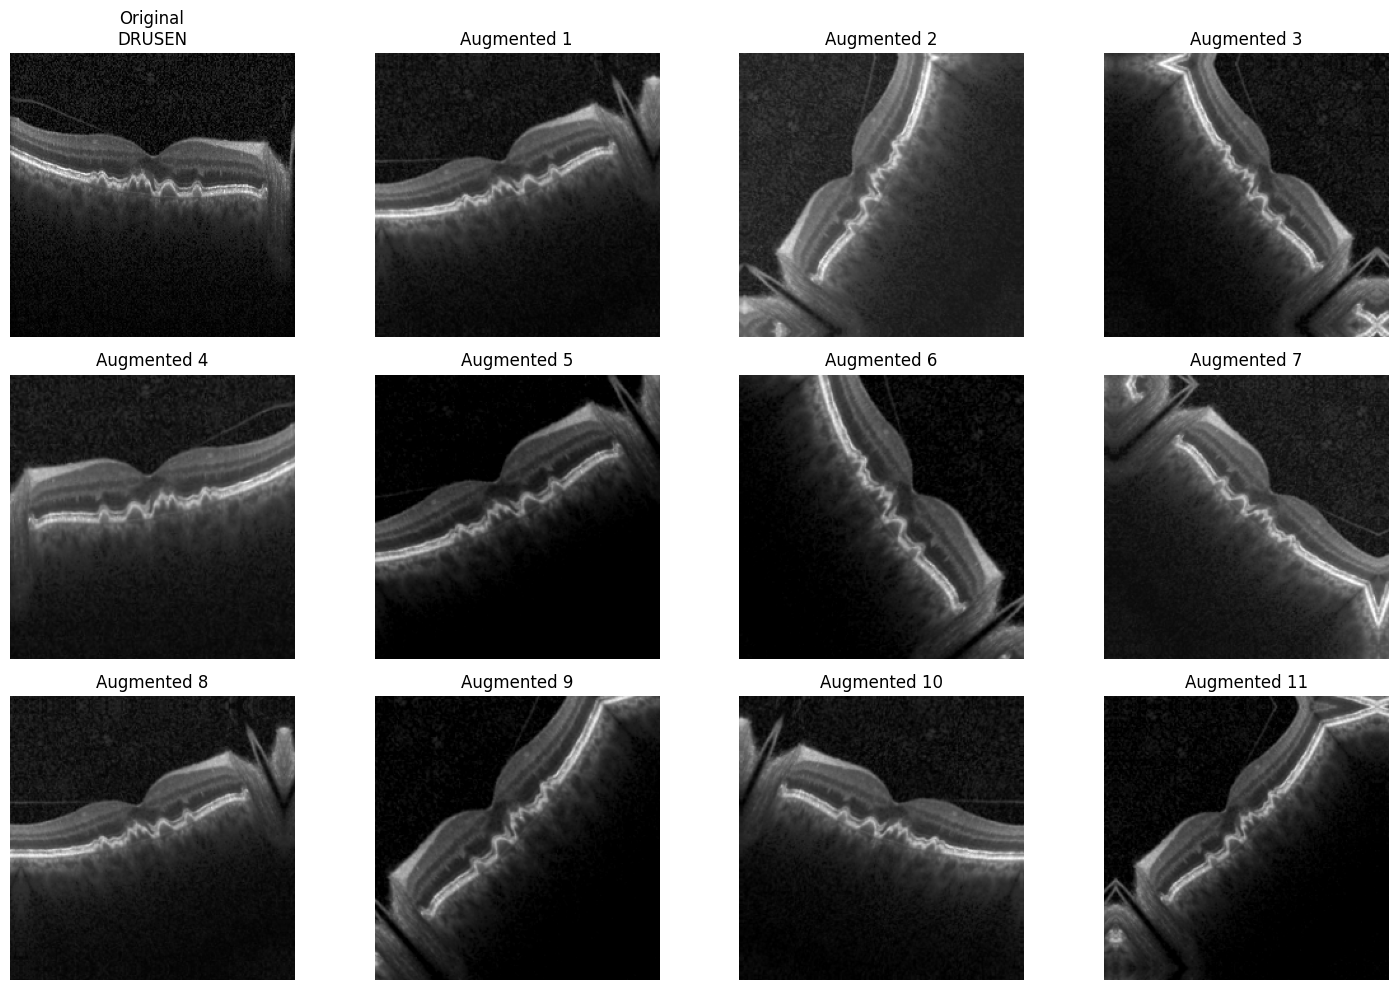

In [6]:
# Visualizar ejemplos de data augmentation
plt.figure(figsize=(15, 10))

# Tomar una imagen del dataset
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    
    # Mostrar la imagen original
    plt.subplot(3, 4, 1)
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.title(f"Original\n{class_names[int(sample_label)]}")
    plt.axis('off')
    
    # Mostrar 11 versiones aumentadas
    for i in range(11):
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
        plt.subplot(3, 4, i + 2)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    
plt.tight_layout()
plt.show()

## 2. Creación y Compilación del Modelo

MobileNetV3 es una arquitectura más eficiente que ResNet50. Descongelaremos sus capas progresivamente para aprovechar al máximo el data augmentation.

In [7]:
from tensorflow.keras.metrics import AUC

# Hiperparámetros configurables
LEARNING_RATE = 1e-5
DROPOUT = 0.4

# 1. Crear el modelo con MobileNetV3
model = mobilenet_model.create_mobilenet_model(
    input_shape=(224, 224, 3), # (Ancho, Alto, Canales RGB)
    num_classes=4, 
    dropout_rate=DROPOUT
)

# 2. Compilar especificando métricas
metrics = [
    'accuracy'
]

model = mobilenet_model.compile_mobilenet_model(
    model, 
    learning_rate=LEARNING_RATE, 
    metrics=metrics
)

model.summary()

Model: "MobileNetV3_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,244,420 (12.38 MB)

 Trainable params: 3,219,508 (12.28 MB)

 Non-trainable params: 24,912 (97.31 KB)

## 3. Entrenamiento con Data Augmentation



In [8]:
EPOCHS = 100

# Obtener callbacks avanzados
callbacks = mobilenet_model.get_mobilenet_callbacks(
    patience_stop=30, 
    patience_lr=2, 
    factor_lr=0.2
)

# Entrenar con el dataset aumentado
history = model.fit(
    train_ds_augmented,  
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1774965575.485887 1160071 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.4475 - loss: 1.3726
Epoch 1: val_loss improved from None to 0.80549, saving model to modelos/best_mobilenetv3.keras

Epoch 1: finished saving model to modelos/best_mobilenetv3.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 198s 394ms/step - accuracy: 0.5912 - loss: 1.0499 - val_accuracy: 0.7128 - val_loss: 0.8055 - learning_rate: 1.0000e-05
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8042 - loss: 0.5622
Epoch 2: val_loss improved from 0.80549 to 0.63937, saving model to modelos/best_mobilenetv3.keras

Epoch 2: finished saving model to modelos/best_mobilenetv3.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.8265 - loss: 0.5014 - val_accuracy: 0.7664 - val_loss: 0.6394 - learning_rate: 1.0000e-05
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8707 - loss: 0.3760
Epoch 3: val_loss improved from 0.63937 to 0.47801, saving model to modelos/best_mobilenetv3.keras

Epoch 3: finished savi

## 4. Curvas de Aprendizaje y Evaluación

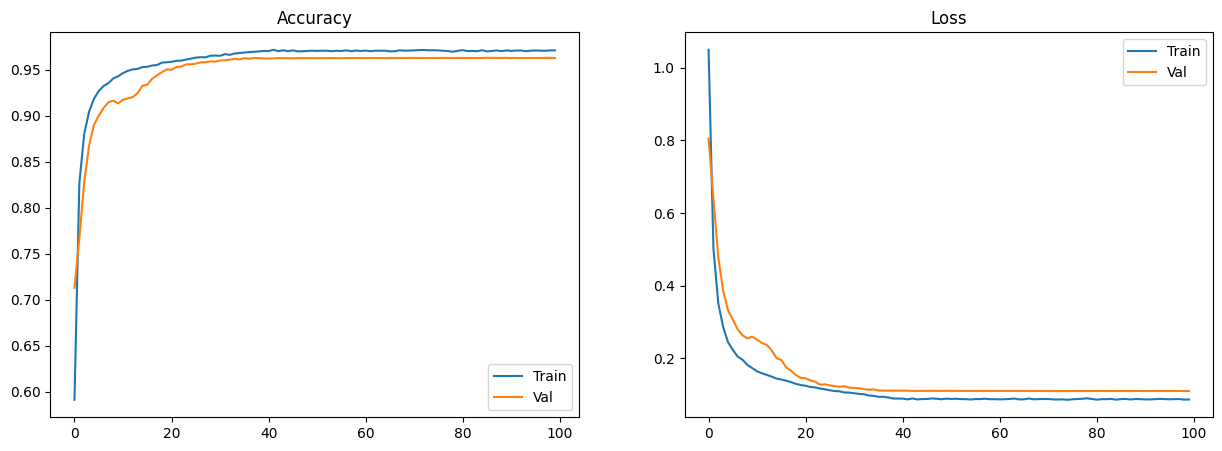

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()



plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()

Loss en test: 0.1169
Accuracy en test: 0.9600

AUC por clase (One-vs-Rest):
 - CNV: 0.9979
 - DME: 0.9962
 - DRUSEN: 0.9838
 - NORMAL: 0.9973

AUC Promedio (Macro): 0.9938

Reporte de clasificacion:
              precision    recall  f1-score   support

         CNV       0.97      0.96      0.97      3746
         DME       0.95      0.92      0.94      1161
      DRUSEN       0.83      0.83      0.83       887
      NORMAL       0.97      0.99      0.98      5139

    accuracy                           0.96     10933
   macro avg       0.93      0.93      0.93     10933
weighted avg       0.96      0.96      0.96     10933



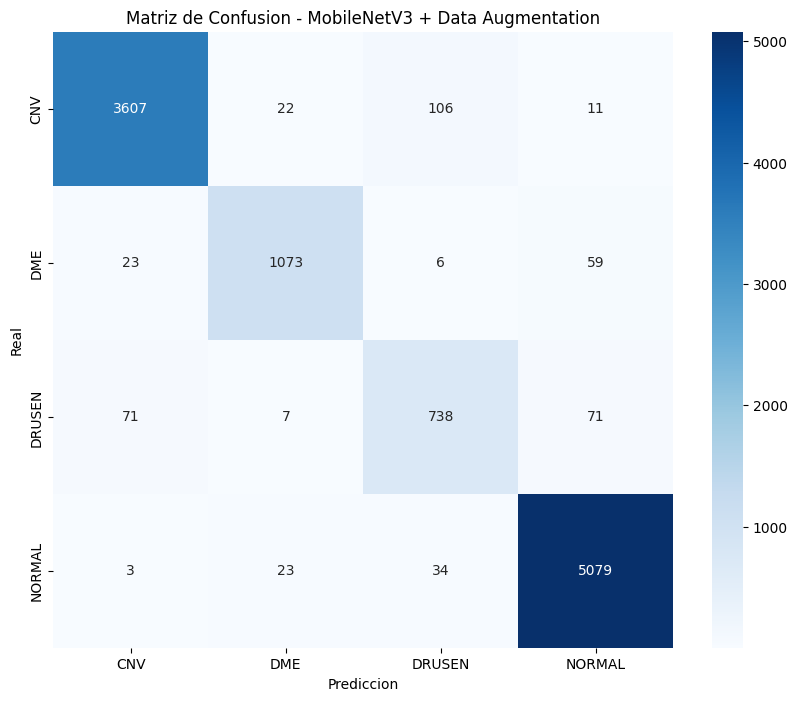

In [10]:
# --- Chunk: Evaluacion de Metricas Finales ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

results = model.evaluate(test_ds, verbose=0)
print(f"Loss en test: {results[0]:.4f}")
print(f"Accuracy en test: {results[1]:.4f}")

y_true = []
y_probs = []

# Obtencion de predicciones
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

# Calculo de AUC por clase
y_true_oh = to_categorical(y_true, num_classes=len(class_names))
print("\nAUC por clase (One-vs-Rest):")
auc_scores = []
for i, class_name in enumerate(class_names):
    auc = roc_auc_score(y_true_oh[:, i], y_probs[:, i])
    auc_scores.append(auc)
    print(f" - {class_name}: {auc:.4f}")

print(f"\nAUC Promedio (Macro): {np.mean(auc_scores):.4f}")

# Reporte de Clasificacion
print("\nReporte de clasificacion:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - MobileNetV3 + Data Augmentation')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()